## 1. Khai báo thư viện & Hằng số

In [69]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV,
    learning_curve, cross_val_score,
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, log_loss,
    balanced_accuracy_score, ConfusionMatrixDisplay,
)
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import BorderlineSMOTE

RANDOM_STATE = 42
TARGET_COLS = [
    "do_an_1_test", "kiem_thu_phan_mem_test", "thiet_ke_web_co_ban_test",
    "cong_nghe_phan_mem_test", "tieng_anh_1_test", "xac_suat_thong_ke_test",
]
DROP_COLS = [
    "student_id", "ky_nang_mem",
    "giao_duc_the_chat_1", "giao_duc_the_chat_2", "giao_duc_the_chat_3",
]
print("Import thanh cong!")

Import thanh cong!


## 2. Doc & Lam sach du lieu

In [70]:
df_raw = pd.read_csv("clean_hk4-ktpm-with-tests.csv")
df = df_raw[df_raw["student_id"].astype(str).str.strip() != "so_tin_chi"].copy()
df.reset_index(drop=True, inplace=True)
df["student_id"] = df["student_id"].astype(str).str.strip()

FEAT_COLS = [c for c in df.columns if c not in TARGET_COLS and c not in DROP_COLS]
for c in FEAT_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# [FIX 3] Nhan int thay vi string
for c in TARGET_COLS:
    df[c] = df[c].astype(str).str.strip().map({"pass": 1, "fail": 0})

print(f"Dataset: {df.shape}  |  Features: {len(FEAT_COLS)}  |  Targets: {len(TARGET_COLS)}")
df.head()

Dataset: (473, 23)  |  Features: 12  |  Targets: 6


,student_id,dai_so_tuyen_tinh,giai_tich,giai_tich_so,kien_truc_may_tinh,lap_trinh_python_co_ban,cau_truc_du_lieu_va_giai_thuat,co_so_ky_thuat_lap_trinh,co_so_du_lieu,lap_trinh_huong_doi_tuong,...,tieng_anh_tang_cuong,giao_duc_the_chat_1,giao_duc_the_chat_2,giao_duc_the_chat_3,cong_nghe_phan_mem_test,do_an_1_test,kiem_thu_phan_mem_test,thiet_ke_web_co_ban_test,tieng_anh_1_test,xac_suat_thong_ke_test
0,12521097,6.7,9.5,9.9,9.5,8.8,9.4,9.1,8.7,9.8,...,6.5,9,7.0,7.0,0,1,1,1,1,1
1,12521054,8.0,9.0,9.3,7.5,7.2,7.9,8.0,8.0,9.2,...,5.5,10,9.0,8.0,1,1,1,1,1,1
2,12521111,2.0,8.1,7.7,7.8,6.3,7.4,7.9,7.5,7.8,...,3.5,8,8.0,7.0,0,1,1,1,1,1
3,10121164,7.3,7.7,3.3,6.5,8.8,5.4,7.5,6.0,7.9,...,3.0,7,7.0,8.0,1,1,1,1,1,1
4,10121688,4.9,8.3,6.3,7.0,7.5,6.2,5.4,6.7,6.9,...,4.0,6,7.0,7.0,1,1,1,1,1,1


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 473 entries, 0 to 472
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   student_id                       473 non-null    object 
 1   dai_so_tuyen_tinh                473 non-null    float64
 2   giai_tich                        473 non-null    float64
 3   giai_tich_so                     472 non-null    float64
 4   kien_truc_may_tinh               473 non-null    float64
 5   lap_trinh_python_co_ban          473 non-null    float64
 6   cau_truc_du_lieu_va_giai_thuat   473 non-null    float64
 7   co_so_ky_thuat_lap_trinh         473 non-null    float64
 8   co_so_du_lieu                    473 non-null    float64
 9   lap_trinh_huong_doi_tuong        473 non-null    float64
 10  lap_trinh_ung_dung_windows_form  472 non-null    float64
 11  phap_luat_dai_cuong              473 non-null    float64
 12  ky_nang_mem           

In [72]:
mv = df[FEAT_COLS].isnull().sum()
print("Gia tri NaN:"); display(mv[mv > 0].rename("NaN count"))

zeros = (df[FEAT_COLS] == 0).sum()
print("\nGia tri = 0 (nghi ngo thieu du lieu):"); display(zeros[zeros > 0].rename("Zero count"))

print("\nThong ke mo ta:"); display(df[FEAT_COLS].describe().round(2))

Gia tri NaN:


,NaN count
giai_tich_so,1
lap_trinh_ung_dung_windows_form,1
tieng_anh_tang_cuong,1



Gia tri = 0 (nghi ngo thieu du lieu):


,Zero count
dai_so_tuyen_tinh,1
giai_tich,5
giai_tich_so,3
kien_truc_may_tinh,4
cau_truc_du_lieu_va_giai_thuat,2
co_so_ky_thuat_lap_trinh,1
co_so_du_lieu,8
lap_trinh_huong_doi_tuong,3
lap_trinh_ung_dung_windows_form,8
phap_luat_dai_cuong,1



Thong ke mo ta:


,dai_so_tuyen_tinh,giai_tich,giai_tich_so,kien_truc_may_tinh,lap_trinh_python_co_ban,cau_truc_du_lieu_va_giai_thuat,co_so_ky_thuat_lap_trinh,co_so_du_lieu,lap_trinh_huong_doi_tuong,lap_trinh_ung_dung_windows_form,phap_luat_dai_cuong,tieng_anh_tang_cuong
count,473.00,473.00,472.00,473.00,473.00,473.00,473.00,473.00,473.00,472.00,473.00,472.00
mean,7.74,7.45,7.01,7.01,7.07,7.13,7.10,6.73,7.20,6.78,7.07,5.81
std,1.26,1.58,1.79,1.69,1.09,1.17,1.36,1.46,1.49,1.91,1.08,2.13
min,0.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.00,6.70,6.20,6.30,6.40,6.40,6.30,6.20,6.60,5.90,6.50,5.00
50%,7.80,7.60,7.30,7.30,7.10,7.20,7.20,6.90,7.40,7.20,7.00,6.50
75%,8.60,8.70,8.30,8.20,7.80,7.90,8.00,7.50,8.20,8.02,7.80,7.00
max,10.00,10.00,10.00,9.80,9.50,9.80,9.80,9.40,9.80,9.60,9.30,8.50


## 3. Kham pha & Truc quan hoa du lieu (EDA)

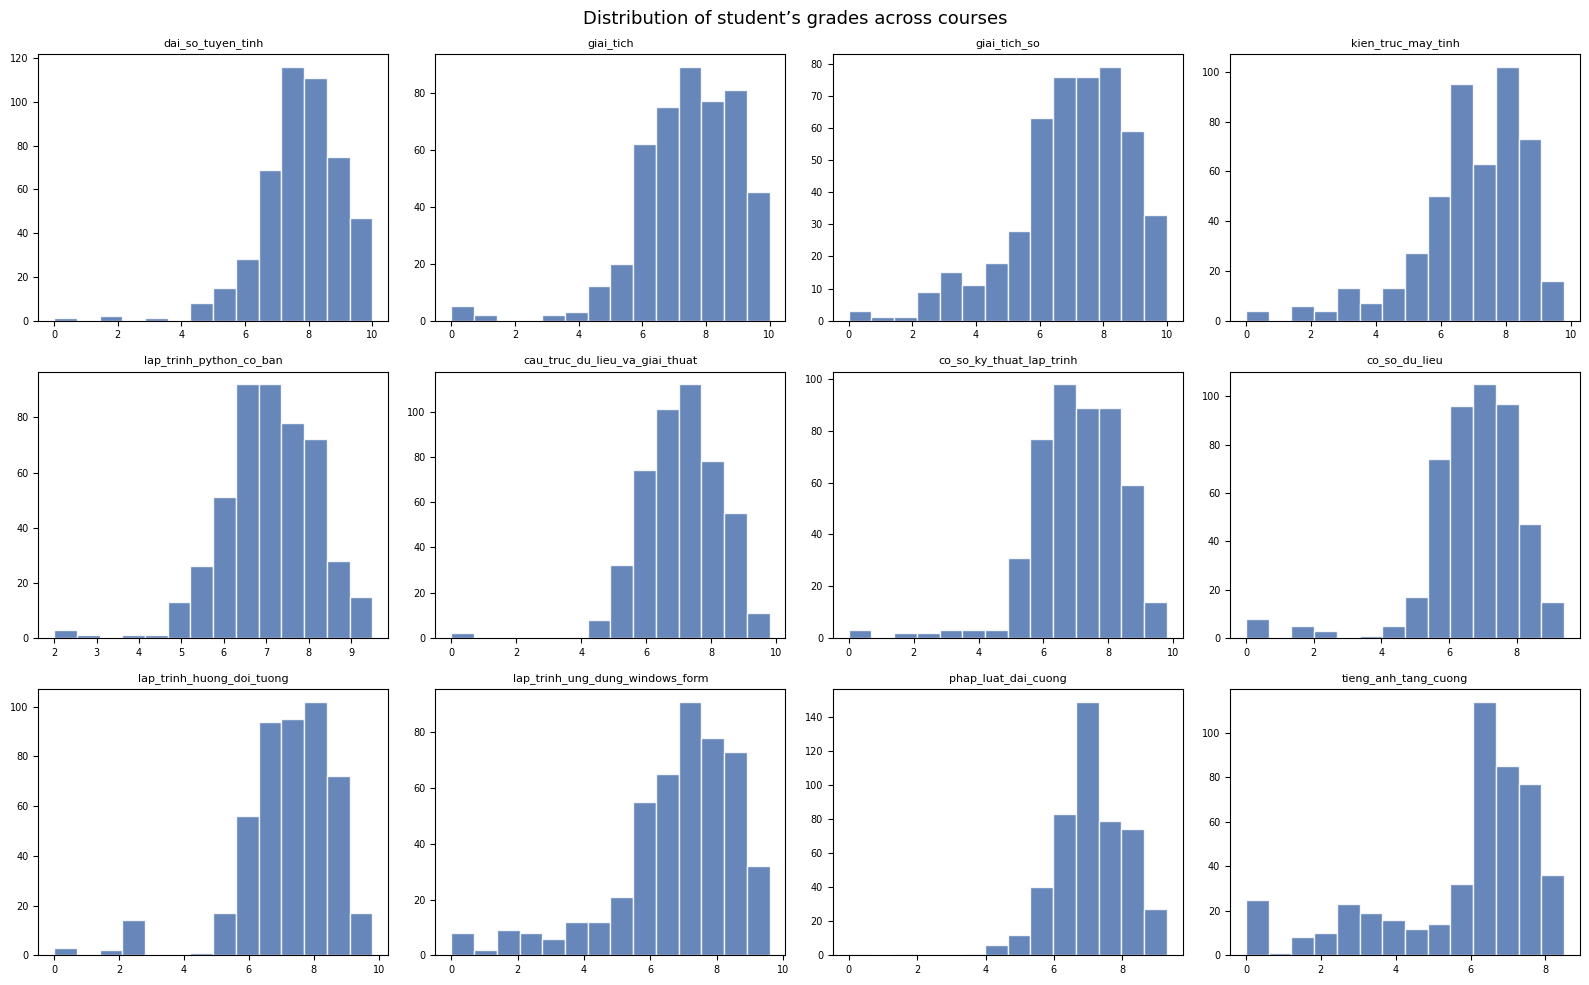

In [73]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, c in zip(axes.flatten(), FEAT_COLS):
    ax.hist(df[c].dropna(), bins=14, color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_title(c, fontsize=8); ax.tick_params(labelsize=7)
for ax in axes.flatten()[len(FEAT_COLS):]: ax.set_visible(False)
plt.suptitle("Distribution of student’s grades across courses", fontsize=13)
plt.tight_layout(); plt.show()

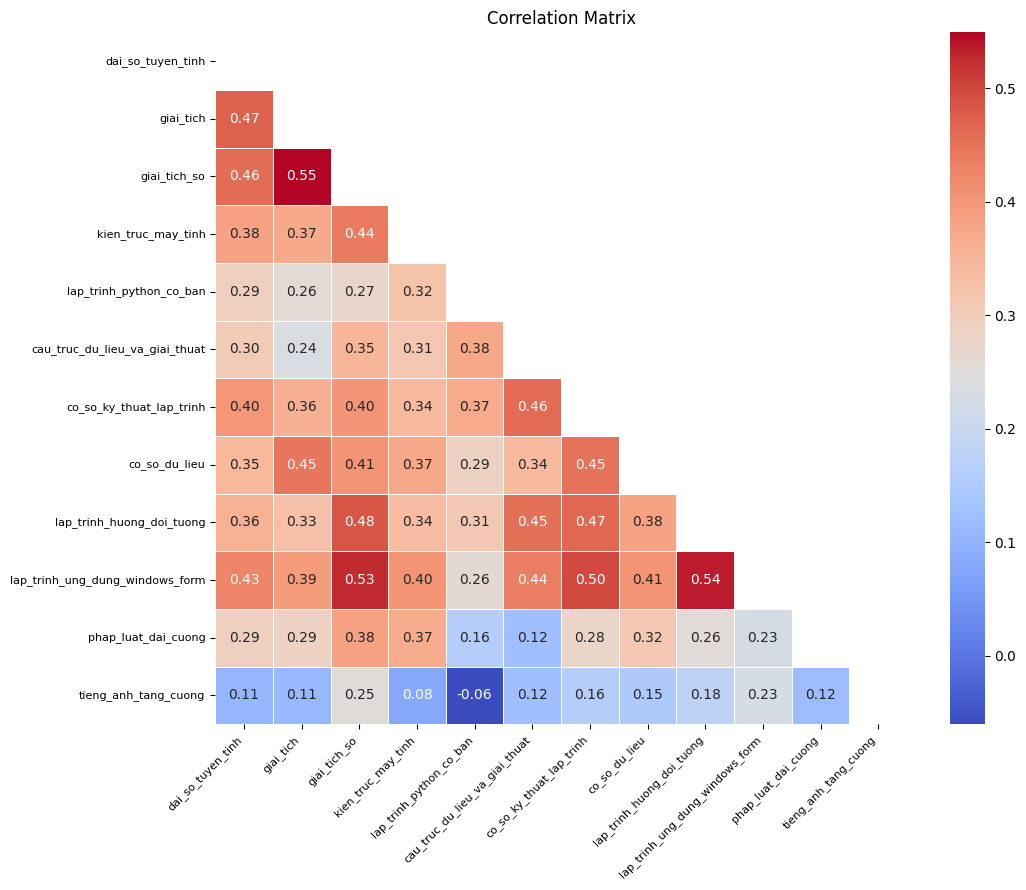

In [74]:
corr = df[FEAT_COLS].corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)),
            annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.4, ax=ax)
plt.xticks(rotation=45, ha="right", fontsize=8); plt.yticks(fontsize=8)
plt.title("Correlation Matrix"); plt.tight_layout(); plt.show()

Ti le Pass/Fail tung mon:
  do_an_1_test                          : Pass=392  Fail= 81  Ratio=4.8:1  Fail%=17.1%
  kiem_thu_phan_mem_test                : Pass=448  Fail= 25  Ratio=17.9:1  Fail%=5.3%
  thiet_ke_web_co_ban_test              : Pass=415  Fail= 58  Ratio=7.2:1  Fail%=12.3%
  cong_nghe_phan_mem_test               : Pass=431  Fail= 42  Ratio=10.3:1  Fail%=8.9%
  tieng_anh_1_test                      : Pass=441  Fail= 32  Ratio=13.8:1  Fail%=6.8%
  xac_suat_thong_ke_test                : Pass=434  Fail= 39  Ratio=11.1:1  Fail%=8.2%


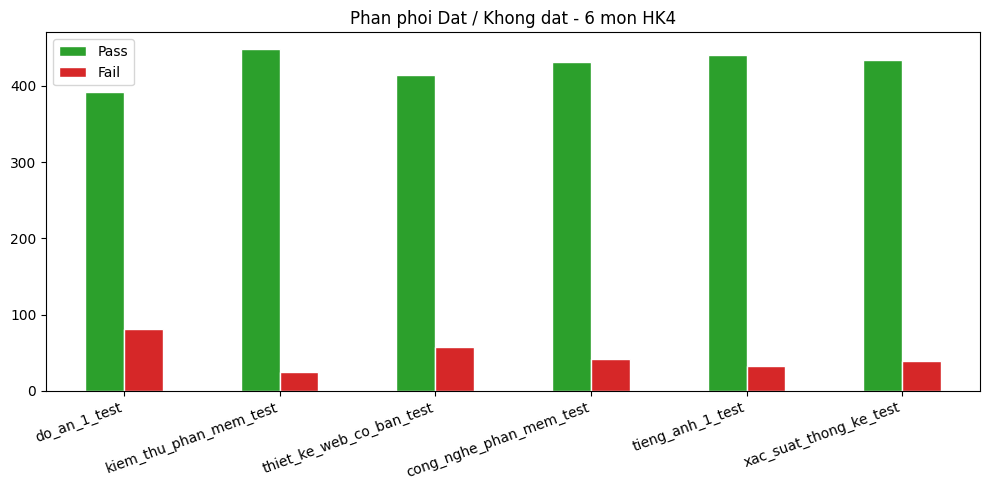

In [75]:
print("Ti le Pass/Fail tung mon:")
for c in TARGET_COLS:
    vc = df[c].value_counts(); p, f = vc.get(1, 0), vc.get(0, 0)
    print(f"  {c:38s}: Pass={p:3d}  Fail={f:3d}  Ratio={p/max(f,1):.1f}:1  Fail%={f/(p+f)*100:.1f}%")

pf = {c: df[c].value_counts().rename({1: "Pass", 0: "Fail"}) for c in TARGET_COLS}
pd.DataFrame(pf).T[["Pass", "Fail"]].plot(
    kind="bar", figsize=(10, 5), color=["#2ca02c", "#d62728"], edgecolor="white")
plt.title("Phan phoi Dat / Khong dat - 6 mon HK4")
plt.xticks(rotation=20, ha="right"); plt.tight_layout(); plt.show()

## 4. Tien xu ly - So sanh truoc/sau [ADD 1]

> **Doi `TARGET`** o o duoi de phan tich mon khac.

In [76]:
#TARGET = "do_an_1_test"               # <- doi tai day

#TARGET = "kiem_thu_phan_mem_test"
#TARGET = "thiet_ke_web_co_ban_test"
#TARGET = "cong_nghe_phan_mem_test"
#TARGET = "tieng_anh_1_test"
TARGET = "xac_suat_thong_ke_test"

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f"Mon dang phan tich: {TARGET}")

Mon dang phan tich: xac_suat_thong_ke_test


In [77]:
y_all = df[TARGET].dropna().astype(int); idx = y_all.index
X_before = df.loc[idx, FEAT_COLS].fillna(0)       # Truoc: fillna=0, khong scale

imp_fit = SimpleImputer(strategy="median")         # [FIX 2]
scl_fit = StandardScaler()
X_after = pd.DataFrame(
    scl_fit.fit_transform(imp_fit.fit_transform(df.loc[idx, FEAT_COLS])),
    columns=FEAT_COLS, index=idx,
)

lr_bare = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
f1_b = cross_val_score(lr_bare, X_before, y_all, cv=cv5, scoring="f1_weighted").mean()
f1_a = cross_val_score(lr_bare, X_after,  y_all, cv=cv5, scoring="f1_weighted").mean()
print(f"LR CV F1 truoc tien xu ly (fillna=0, no scale)      : {f1_b:.4f}")
print(f"LR CV F1 sau tien xu ly   (Median + StandardScaler) : {f1_a:.4f}")
print(f"Cai thien: {(f1_a - f1_b)*100:+.2f}%")

print("\n[Truoc tien xu ly]:")
display(X_before.describe().round(2))
print("\n[Sau tien xu ly: Median Imputer + StandardScaler]:")
display(X_after.describe().round(2))

LR CV F1 truoc tien xu ly (fillna=0, no scale)      : 0.8937
LR CV F1 sau tien xu ly   (Median + StandardScaler) : 0.8947
Cai thien: +0.11%

[Truoc tien xu ly]:


,dai_so_tuyen_tinh,giai_tich,giai_tich_so,kien_truc_may_tinh,lap_trinh_python_co_ban,cau_truc_du_lieu_va_giai_thuat,co_so_ky_thuat_lap_trinh,co_so_du_lieu,lap_trinh_huong_doi_tuong,lap_trinh_ung_dung_windows_form,phap_luat_dai_cuong,tieng_anh_tang_cuong
count,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00
mean,7.74,7.45,7.00,7.01,7.07,7.13,7.10,6.73,7.20,6.76,7.07,5.80
std,1.26,1.58,1.81,1.69,1.09,1.17,1.36,1.46,1.49,1.93,1.08,2.15
min,0.00,0.00,0.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,7.00,6.70,6.20,6.30,6.40,6.40,6.30,6.20,6.60,5.90,6.50,5.00
50%,7.80,7.60,7.30,7.30,7.10,7.20,7.20,6.90,7.40,7.20,7.00,6.50
75%,8.60,8.70,8.30,8.20,7.80,7.90,8.00,7.50,8.20,8.00,7.80,7.00
max,10.00,10.00,10.00,9.80,9.50,9.80,9.80,9.40,9.80,9.60,9.30,8.50



[Sau tien xu ly: Median Imputer + StandardScaler]:


,dai_so_tuyen_tinh,giai_tich,giai_tich_so,kien_truc_may_tinh,lap_trinh_python_co_ban,cau_truc_du_lieu_va_giai_thuat,co_so_ky_thuat_lap_trinh,co_so_du_lieu,lap_trinh_huong_doi_tuong,lap_trinh_ung_dung_windows_form,phap_luat_dai_cuong,tieng_anh_tang_cuong
count,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00,473.00
mean,-0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-6.17,-4.71,-3.93,-4.16,-4.66,-6.12,-5.24,-4.62,-4.83,-3.56,-6.55,-2.73
25%,-0.59,-0.47,-0.46,-0.42,-0.62,-0.63,-0.59,-0.36,-0.40,-0.46,-0.53,-0.38
50%,0.05,0.10,0.16,0.17,0.03,0.06,0.08,0.12,0.13,0.22,-0.06,0.32
75%,0.69,0.79,0.72,0.71,0.67,0.66,0.67,0.53,0.67,0.64,0.68,0.56
max,1.80,1.61,1.67,1.65,2.23,2.29,2.00,1.83,1.74,1.48,2.07,1.26


## Ham tien ich (dung chung cho cac buoc sau)

In [78]:
def prepare(target):
    ids = df["student_id"]
    X   = df.drop(columns=TARGET_COLS + DROP_COLS, errors="ignore")
    y   = df[target].dropna().astype(int)
    X, y, ids = X.loc[y.index], y, ids.loc[y.index]
    Xtr, Xte, ytr, yte, itr, ite = train_test_split(
        X, y, ids, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    return (X.reset_index(drop=True),   y.reset_index(drop=True),
            Xtr.reset_index(drop=True), Xte.reset_index(drop=True),
            ytr.reset_index(drop=True), yte.reset_index(drop=True),
            itr.reset_index(drop=True), ite.reset_index(drop=True))


def new_smote(k):
    """[FIX 1] Luon tao instance moi."""
    return BorderlineSMOTE(sampling_strategy=1.0, k_neighbors=max(1, k),
                           random_state=RANDOM_STATE)


def build_models(k_smote):
    """[FIX 1+2] SMOTE instance rieng, Median Imputer. Feature selection tach biet."""
    return {
        "Logistic Regression": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("smote", new_smote(k_smote)),
            ("scl",   StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced",
                                         random_state=RANDOM_STATE)),
        ]),
        "KNN": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("smote", new_smote(k_smote)),
            ("scl",   StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=15, weights="uniform")),
        ]),
        "Random Forest": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("smote", new_smote(k_smote)),
            ("model", RandomForestClassifier(
                n_estimators=200, max_depth=3, min_samples_leaf=10,
                min_samples_split=20, max_features="sqrt",
                class_weight="balanced_subsample", random_state=RANDOM_STATE)),
        ]),
        "SVM": Pipeline([
            ("imp",   SimpleImputer(strategy="median")),
            ("smote", new_smote(k_smote)),
            ("scl",   StandardScaler()),
            ("model", SVC(kernel="rbf", class_weight="balanced",
                          probability=True, random_state=RANDOM_STATE)),
        ]),
    }

print("Da dinh nghia: prepare(), new_smote(), build_models(k_smote)")


Da dinh nghia: prepare(), new_smote(), build_models(k_smote)


## 5. Lua chon dac trung [ADD 2]


In [79]:
Xf, yf, Xtr, Xte, ytr, yte, *_ = prepare(TARGET)
k_sm = min(2, int(ytr.value_counts().min()) - 1)

imp2 = SimpleImputer(strategy="median"); scl2 = StandardScaler()
Xtr_sc = pd.DataFrame(scl2.fit_transform(imp2.fit_transform(Xtr)), columns=FEAT_COLS)
Xte_sc = pd.DataFrame(scl2.transform(imp2.transform(Xte)), columns=FEAT_COLS)
Xtr_sm, ytr_sm = new_smote(k_sm).fit_resample(Xtr_sc, ytr)
Xtr_sm = pd.DataFrame(Xtr_sm, columns=FEAT_COLS)
print(f"Train sau SMOTE: {Counter(ytr_sm)}")

Train sau SMOTE: Counter({1: 347, 0: 347})


### Kiểm tra phân phối Train/Test

Xác nhận `stratify` hoạt động đúng: tỉ lệ Pass/Fail phải **tương đồng** giữa train và test, và phân phối các đặc trưng không bị lệch.

In [80]:
# ── 1. Phân phối nhãn ────────────────────────────────────────────────────────
print(f"Phân phối nhãn – {TARGET}")
print(f"{'':30s}  {'Train':>18s}  {'Test':>18s}  {'Chênh lệch':>12s}")
print("-" * 82)
for label, name in [(0, "Fail"), (1, "Pass")]:
    n_tr = int((ytr == label).sum()); n_te = int((yte == label).sum())
    p_tr = n_tr / len(ytr) * 100;    p_te = n_te / len(yte) * 100
    diff = abs(p_tr - p_te)
    print(f"  {name} ({label}){'':26s}  {n_tr:3d} ({p_tr:5.1f}%)  {n_te:3d} ({p_te:5.1f}%)  {diff:+.2f}%")
print("-" * 82)
print(f"  Tổng{'':28s}  {len(ytr):3d} (100.0%)  {len(yte):3d} (100.0%)")

diff_fail = abs((ytr==0).sum()/len(ytr) - (yte==0).sum()/len(yte)) * 100
print(f"\n→ Chênh lệch tỉ lệ Fail: {diff_fail:.2f}%  ", end="")
print("✅ Stratified split chuẩn" if diff_fail < 1 else "⚠️ Phân phối lệch – kiểm tra lại")

#vẽ biểu đồ phân phối nhãn trên tập train và test


Phân phối nhãn – xac_suat_thong_ke_test
                                             Train                Test    Chênh lệch
----------------------------------------------------------------------------------
  Fail (0)                             31 (  8.2%)    8 (  8.4%)  +0.22%
  Pass (1)                            347 ( 91.8%)   87 ( 91.6%)  +0.22%
----------------------------------------------------------------------------------
  Tổng                              378 (100.0%)   95 (100.0%)

→ Chênh lệch tỉ lệ Fail: 0.22%  ✅ Stratified split chuẩn


3 phuong phap xep hang: **F-score**, **Mutual Information**, **RF Feature Importance**

In [81]:
sel_f = SelectKBest(f_classif, k="all").fit(Xtr_sm, ytr_sm)
mi    = mutual_info_classif(Xtr_sm, ytr_sm, random_state=RANDOM_STATE)
rf_fi = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE).fit(Xtr_sm, ytr_sm)

rank_df = pd.DataFrame({
    "Dac trung": FEAT_COLS,
    "F-score":   np.round(sel_f.scores_, 2),
    "Mut.Info":  np.round(mi, 4),
    "RF Imp.":   np.round(rf_fi.feature_importances_, 4),
})
rank_df["Avg Rank"] = (
    rank_df["F-score"].rank(ascending=False) +
    rank_df["Mut.Info"].rank(ascending=False) +
    rank_df["RF Imp."].rank(ascending=False)) / 3
rank_df = rank_df.sort_values("Avg Rank").reset_index(drop=True)
display(rank_df)

,Dac trung,F-score,Mut.Info,RF Imp.,Avg Rank
0,giai_tich_so,712.52,0.4197,0.2779,1.000000
1,giai_tich,328.61,0.4038,0.1539,3.333333
2,lap_trinh_ung_dung_windows_form,441.34,0.3967,0.1557,3.333333
3,kien_truc_may_tinh,420.73,0.4029,0.1109,3.666667
4,dai_so_tuyen_tinh,283.14,0.3902,0.0557,6.000000
5,co_so_ky_thuat_lap_trinh,158.04,0.4050,0.0296,7.333333
6,phap_luat_dai_cuong,212.58,0.3842,0.0378,7.666667
7,lap_trinh_huong_doi_tuong,172.77,0.3654,0.0468,8.000000
8,cau_truc_du_lieu_va_giai_thuat,140.66,0.3926,0.0337,8.666667
9,co_so_du_lieu,178.02,0.3438,0.0440,8.666667


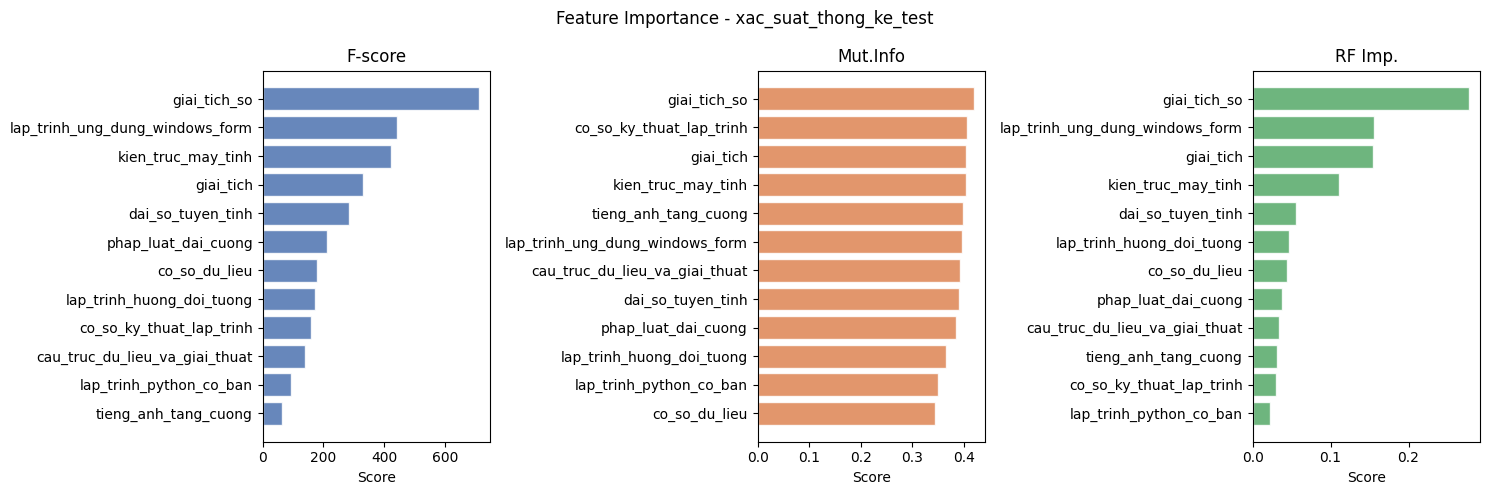

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, color) in zip(axes, [("F-score","#4C72B0"),("Mut.Info","#dd8452"),("RF Imp.","#55a868")]):
    sdf = rank_df.sort_values(col)
    ax.barh(sdf["Dac trung"], sdf[col], color=color, edgecolor="white", alpha=0.85)
    ax.set_title(col); ax.set_xlabel("Score")
plt.suptitle(f"Feature Importance - {TARGET}", fontsize=12)
plt.tight_layout(); plt.show()

In [83]:
# Buoc 1: Loc theo Avg Rank threshold
AVG_RANK_THRESHOLD = 8
candidates = rank_df[rank_df["Avg Rank"] <= AVG_RANK_THRESHOLD]["Dac trung"].tolist()
print(f"Features sau loc Avg Rank <= {AVG_RANK_THRESHOLD} ({len(candidates)} features):")
display(rank_df[rank_df["Avg Rank"] <= AVG_RANK_THRESHOLD][["Dac trung","F-score","Mut.Info","RF Imp.","Avg Rank"]])

# Buoc 2: Loai features tuong quan cao (> 0.8) tren train set
corr_mat = Xtr_sm[candidates].corr().abs()
selected = candidates.copy()
removed_pairs = []
for i in range(len(candidates)):
    for j in range(i + 1, len(candidates)):
        f1, f2 = candidates[i], candidates[j]
        if f1 in selected and f2 in selected:
            if corr_mat.loc[f1, f2] > 0.8:
                rank_f1 = rank_df[rank_df["Dac trung"] == f1]["Avg Rank"].values[0]
                rank_f2 = rank_df[rank_df["Dac trung"] == f2]["Avg Rank"].values[0]
                drop = f2 if rank_f1 <= rank_f2 else f1
                selected.remove(drop)
                removed_pairs.append((f1, f2, corr_mat.loc[f1, f2], drop))

if removed_pairs:
    print("\nLoai do tuong quan cao (> 0.8):")
    for f1, f2, c, drop in removed_pairs:
        keep = f2 if drop == f1 else f1
        print(f"  {f1} <-> {f2}: corr={c:.2f} -> loai '{drop}', giu '{keep}'")
else:
    print("\nKhong co cap features nao tuong quan > 0.8")

SELECTED_FEATURES = selected
print(f"\nTap features co dinh ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")


Features sau loc Avg Rank <= 8 (8 features):


,Dac trung,F-score,Mut.Info,RF Imp.,Avg Rank
0,giai_tich_so,712.52,0.4197,0.2779,1.000000
1,giai_tich,328.61,0.4038,0.1539,3.333333
2,lap_trinh_ung_dung_windows_form,441.34,0.3967,0.1557,3.333333
3,kien_truc_may_tinh,420.73,0.4029,0.1109,3.666667
4,dai_so_tuyen_tinh,283.14,0.3902,0.0557,6.000000
5,co_so_ky_thuat_lap_trinh,158.04,0.4050,0.0296,7.333333
6,phap_luat_dai_cuong,212.58,0.3842,0.0378,7.666667
7,lap_trinh_huong_doi_tuong,172.77,0.3654,0.0468,8.000000



Khong co cap features nao tuong quan > 0.8

Tap features co dinh (8): ['giai_tich_so', 'giai_tich', 'lap_trinh_ung_dung_windows_form', 'kien_truc_may_tinh', 'dai_so_tuyen_tinh', 'co_so_ky_thuat_lap_trinh', 'phap_luat_dai_cuong', 'lap_trinh_huong_doi_tuong']


## 6. Huan luyen mo hinh – Ket qua Baseline

Train 4 model voi **params mac dinh** tren tap train, danh gia tren tap test.
Ket qua nay dung de so sanh voi Section 7 (sau GridSearchCV).

In [84]:
baseline_pipes = build_models(k_sm)
baseline_rows = []

Xtr_sel = Xtr[SELECTED_FEATURES]
Xte_sel = Xte[SELECTED_FEATURES]

for name, pipe in baseline_pipes.items():
    pipe.fit(Xtr_sel, ytr)
    yp = pipe.predict(Xte_sel)
    pp = pipe.predict_proba(Xte_sel)
    baseline_rows.append({
        "Mo hinh":              name,
        "Accuracy":             round(accuracy_score(yte, yp), 4),
        "Precision (macro)":    round(precision_score(yte, yp, average="macro",    zero_division=0), 4),
        "Recall (macro)":       round(recall_score(yte, yp,    average="macro",    zero_division=0), 4),
        "F1 (macro)":           round(f1_score(yte, yp,        average="macro",    zero_division=0), 4),
        "Precision (weighted)": round(precision_score(yte, yp, average="weighted", zero_division=0), 4),
        "Recall (weighted)":    round(recall_score(yte, yp,    average="weighted", zero_division=0), 4),
        "F1 (weighted)":        round(f1_score(yte, yp,        average="weighted", zero_division=0), 4),
        "Log Loss":             round(log_loss(yte, pp), 4),
    })

baseline_df = pd.DataFrame(baseline_rows).sort_values("F1 (macro)", ascending=False)
print(f"Ket qua BASELINE (params mac dinh, {len(SELECTED_FEATURES)} features) - {TARGET}:")
display(baseline_df)


Ket qua BASELINE (params mac dinh, 8 features) - xac_suat_thong_ke_test:


,Mo hinh,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),Log Loss
0,Logistic Regression,0.8842,0.6875,0.8233,0.7279,0.9266,0.8842,0.8994,0.3534
1,KNN,0.8526,0.6683,0.8628,0.7068,0.9331,0.8526,0.8788,1.4023
2,Random Forest,0.8737,0.6426,0.7040,0.6647,0.8997,0.8737,0.8848,0.2717
3,SVM,0.8737,0.6206,0.6473,0.6318,0.8872,0.8737,0.8800,0.3899


## 7. Tinh chinh tham so - GridSearchCV [ADD 3]

In [85]:
# [ADD 3] GridSearchCV chi tune hyperparameter model, feature da chon o Section 5
param_grids = {
    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
    },
    "KNN": {
        "model__n_neighbors":  [9, 11, 13, 15, 21],
        "model__weights":      ["uniform"],
    },
    "Random Forest": {
        "model__max_depth":        [2, 3, 4],
        "model__min_samples_leaf": [8, 12, 20],
        "model__n_estimators":     [100, 200],
    },
    "SVM": {
        "model__C":      [0.1, 1, 10],
        "model__kernel": ["rbf", "linear"],
    },
}

Xtr_sel = Xtr[SELECTED_FEATURES]
Xte_sel = Xte[SELECTED_FEATURES]

tuned_pipes = {}; gs_rows = []
for name, pipe in build_models(k_sm).items():
    print(f"[{name}] searching...")
    grid = GridSearchCV(pipe, param_grids[name], cv=cv5,
                        scoring="f1_macro", n_jobs=1, verbose=0)
    grid.fit(Xtr_sel, ytr)
    best = grid.best_estimator_; tuned_pipes[name] = best

    yp = best.predict(Xte_sel); pp = best.predict_proba(Xte_sel)
    rec_fail = recall_score(yte, yp, labels=[0], average=None, zero_division=0)[0]
    f1m = f1_score(yte, yp, average="macro",    zero_division=0)
    f1w = f1_score(yte, yp, average="weighted", zero_division=0)
    gs_rows.append({
        "Mo hinh":       name,
        "Best params":   str({k.replace("model__",""):v for k,v in grid.best_params_.items()}),
        "CV F1 macro":   round(grid.best_score_, 4),
        "Test F1 macro": round(f1m, 4),
        "Test F1 w":     round(f1w, 4),
        "Recall Fail":   round(rec_fail, 4),
        "Log Loss":      round(log_loss(yte, pp), 4),
    })
    print(f"  -> Best: {grid.best_params_}  CV={grid.best_score_:.4f}  RecFail={rec_fail:.4f}\n")

print(f"Ket qua GridSearchCV ({len(SELECTED_FEATURES)} features):"); display(pd.DataFrame(gs_rows))

[Logistic Regression] searching...
  -> Best: {'model__C': 0.01}  CV=0.6463  RecFail=0.7500

[KNN] searching...
  -> Best: {'model__n_neighbors': 9, 'model__weights': 'uniform'}  CV=0.5998  RecFail=0.6250

[Random Forest] searching...
  -> Best: {'model__max_depth': 3, 'model__min_samples_leaf': 8, 'model__n_estimators': 100}  CV=0.6603  RecFail=0.5000

[SVM] searching...
  -> Best: {'model__C': 0.1, 'model__kernel': 'rbf'}  CV=0.6234  RecFail=0.6250

Ket qua GridSearchCV (8 features):


,Mo hinh,Best params,CV F1 macro,Test F1 macro,Test F1 w,Recall Fail,Log Loss
0,Logistic Regression,{'C': 0.01},0.6463,0.7430,0.9072,0.750,0.3716
1,KNN,"{'n_neighbors': 9, 'weights': 'uniform'}",0.5998,0.6545,0.8662,0.625,2.0960
2,Random Forest,"{'max_depth': 3, 'min_samples_leaf': 8, 'n_est...",0.6603,0.6647,0.8848,0.500,0.2684
3,SVM,"{'C': 0.1, 'kernel': 'rbf'}",0.6234,0.6435,0.8588,0.625,0.2897


## 8. So sanh Baseline vs Tuned + Phan tich Overfitting [FIX 6 / ADD 4]

**Phan 1** – So sanh F1 macro / F1 weighted / Log Loss truoc va sau GridSearchCV.  
**Phan 2** – Kiem tra overfitting tren model da tune: Gap F1 > 0.05 hoac Gap Loss > 0.2 la canh bao.

In [86]:
# ── Phan 1: So sanh Baseline vs Tuned ────────────────────────────────────────
tuned_cmp = []
for name, pipe in tuned_pipes.items():
    yp = pipe.predict(Xte_sel); pp = pipe.predict_proba(Xte_sel)
    tuned_cmp.append({
        "Mo hinh":           name,
        "F1 macro (tuned)":  round(f1_score(yte, yp, average="macro",    zero_division=0), 4),
        "F1 w (tuned)":      round(f1_score(yte, yp, average="weighted", zero_division=0), 4),
        "Log Loss (tuned)":  round(log_loss(yte, pp), 4),
    })

base_cmp = (baseline_df.set_index("Mo hinh")
            [["F1 (macro)", "F1 (weighted)", "Log Loss"]]
            .rename(columns={"F1 (macro)": "F1 macro (base)",
                              "F1 (weighted)": "F1 w (base)",
                              "Log Loss": "Log Loss (base)"}))
tuned_cmp_df = pd.DataFrame(tuned_cmp).set_index("Mo hinh")

cmp_df = base_cmp.join(tuned_cmp_df)
cmp_df = cmp_df.reindex(list(tuned_pipes.keys()))  # dong bo thu tu voi tuned_pipes va of_df
cmp_df["Delta F1 macro"] = (cmp_df["F1 macro (tuned)"] - cmp_df["F1 macro (base)"]).round(4)
cmp_df["Delta F1 w"]     = (cmp_df["F1 w (tuned)"]     - cmp_df["F1 w (base)"]).round(4)

print("── So sanh Baseline vs Tuned ──")
display(cmp_df[["F1 macro (base)", "F1 macro (tuned)", "Delta F1 macro",
                "F1 w (base)",     "F1 w (tuned)",     "Delta F1 w",
                "Log Loss (base)", "Log Loss (tuned)"]])

# ── Phan 2: Overfitting (tren model da tune) ──────────────────────────────────
of_rows = []
for name, pipe in tuned_pipes.items():
    yp_tr = pipe.predict(Xtr_sel);  yp_te = pipe.predict(Xte_sel)
    pp_tr = pipe.predict_proba(Xtr_sel); pp_te = pipe.predict_proba(Xte_sel)
    f1_tr = f1_score(ytr, yp_tr, average="weighted", zero_division=0)
    f1_te = f1_score(yte, yp_te, average="weighted", zero_division=0)
    ll_tr = log_loss(ytr, pp_tr); ll_te = log_loss(yte, pp_te)
    of_rows.append({
        "Mo hinh":    name,
        "Train F1":   round(f1_tr, 4),
        "Test F1":    round(f1_te, 4),
        "Gap F1":     round(f1_tr - f1_te, 4),
        "Train Loss": round(ll_tr, 4),
        "Test Loss":  round(ll_te, 4),
        "Gap Loss":   round(ll_te - ll_tr, 4),
        "Nhan xet":   "Overfit" if (f1_tr - f1_te) > 0.05 or (ll_te - ll_tr) > 0.2 else "On",
    })

# of_df thu tu: LR, KNN, RF, SVM (theo tuned_pipes) – khop voi cmp_df sau reindex
of_df = pd.DataFrame(of_rows).set_index("Mo hinh")
print("\n── Overfitting (model da tune) ──")
display(of_df)

── So sanh Baseline vs Tuned ──


,F1 macro (base),F1 macro (tuned),Delta F1 macro,F1 w (base),F1 w (tuned),Delta F1 w,Log Loss (base),Log Loss (tuned)
Mo hinh,,,,,,,,
Logistic Regression,0.7279,0.7430,0.0151,0.8994,0.9072,0.0078,0.3534,0.3716
KNN,0.7068,0.6545,-0.0523,0.8788,0.8662,-0.0126,1.4023,2.0960
Random Forest,0.6647,0.6647,0.0000,0.8848,0.8848,0.0000,0.2717,0.2684
SVM,0.6318,0.6435,0.0117,0.8800,0.8588,-0.0212,0.3899,0.2897



── Overfitting (model da tune) ──


,Train F1,Test F1,Gap F1,Train Loss,Test Loss,Gap Loss,Nhan xet
Mo hinh,,,,,,,
Logistic Regression,0.8619,0.9072,-0.0453,0.4018,0.3716,-0.0302,On
KNN,0.8601,0.8662,-0.0062,0.3007,2.0960,1.7953,Overfit
Random Forest,0.8993,0.8848,0.0144,0.2941,0.2684,-0.0257,On
SVM,0.8530,0.8588,-0.0058,0.2975,0.2897,-0.0078,On


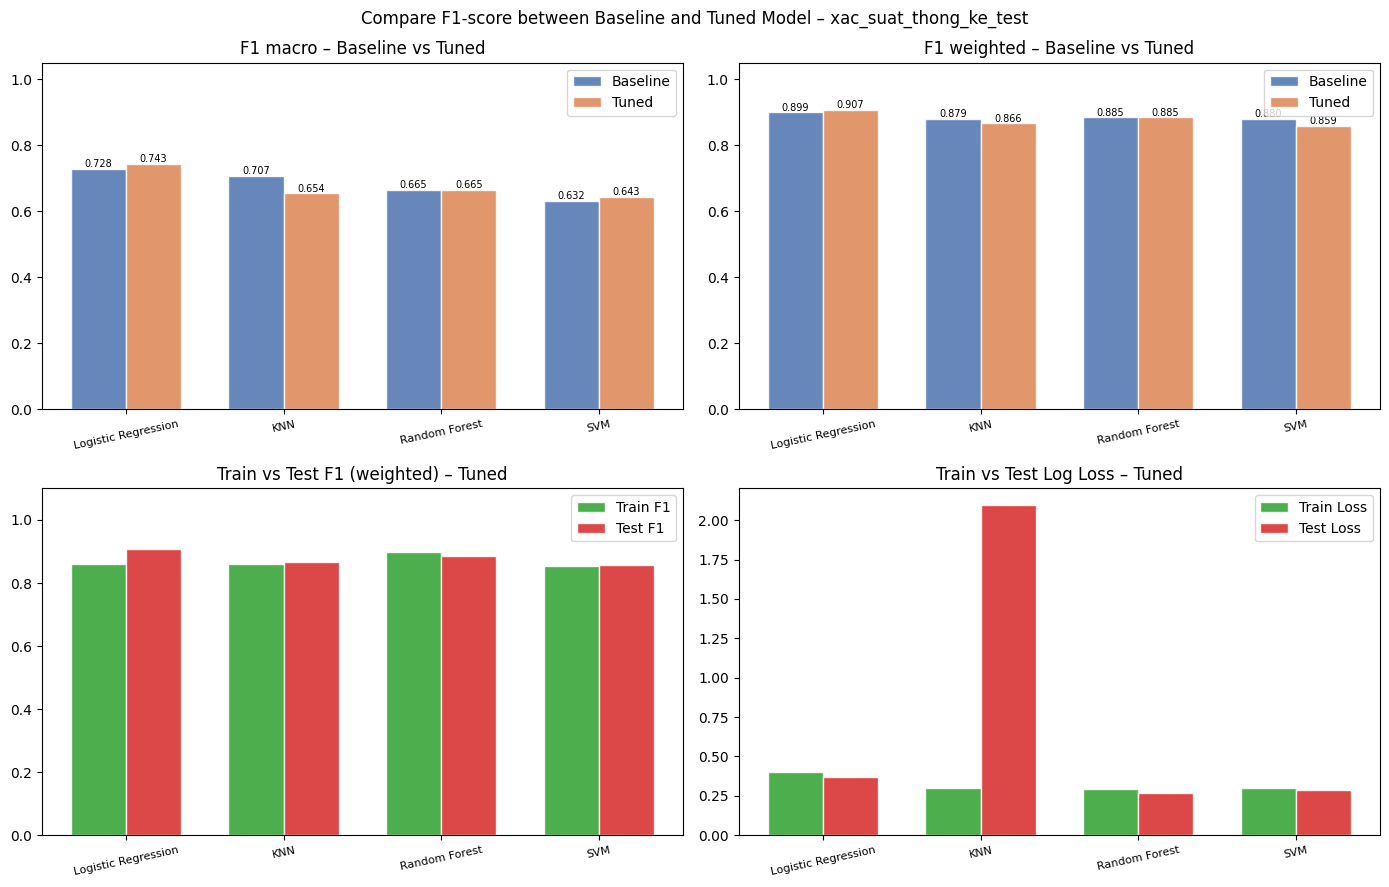

In [87]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
models = list(cmp_df.index)
x = np.arange(len(models)); w = 0.35

# ── Bieu do 1: F1 macro Baseline vs Tuned ────────────────────────────────────
ax = axes[0, 0]
ax.bar(x - w/2, cmp_df["F1 macro (base)"],  w, label="Baseline", color="#4C72B0", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, cmp_df["F1 macro (tuned)"], w, label="Tuned",    color="#dd8452", alpha=0.85, edgecolor="white")
for i, (b, t) in enumerate(zip(cmp_df["F1 macro (base)"], cmp_df["F1 macro (tuned)"])):
    ax.text(i - w/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=7)
    ax.text(i + w/2, t + 0.005, f"{t:.3f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=12, fontsize=8)
ax.set_ylim(0, 1.05); ax.set_title("F1 macro – Baseline vs Tuned"); ax.legend()

# ── Bieu do 2: F1 weighted Baseline vs Tuned ─────────────────────────────────
ax = axes[0, 1]
ax.bar(x - w/2, cmp_df["F1 w (base)"],  w, label="Baseline", color="#4C72B0", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, cmp_df["F1 w (tuned)"], w, label="Tuned",    color="#dd8452", alpha=0.85, edgecolor="white")
for i, (b, t) in enumerate(zip(cmp_df["F1 w (base)"], cmp_df["F1 w (tuned)"])):
    ax.text(i - w/2, b + 0.005, f"{b:.3f}", ha="center", fontsize=7)
    ax.text(i + w/2, t + 0.005, f"{t:.3f}", ha="center", fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(models, rotation=12, fontsize=8)
ax.set_ylim(0, 1.05); ax.set_title("F1 weighted – Baseline vs Tuned"); ax.legend()

# ── Bieu do 3: Train vs Test F1 (overfitting) ─────────────────────────────────
ax = axes[1, 0]
ax.bar(x - w/2, of_df["Train F1"], w, label="Train F1", color="#2ca02c", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, of_df["Test F1"],  w, label="Test F1",  color="#d62728", alpha=0.85, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(of_df.index, rotation=12, fontsize=8)
ax.set_ylim(0, 1.1); ax.set_title("Train vs Test F1 (weighted) – Tuned"); ax.legend()

# ── Bieu do 4: Train vs Test Log Loss (overfitting) ───────────────────────────
ax = axes[1, 1]
ax.bar(x - w/2, of_df["Train Loss"], w, label="Train Loss", color="#2ca02c", alpha=0.85, edgecolor="white")
ax.bar(x + w/2, of_df["Test Loss"],  w, label="Test Loss",  color="#d62728", alpha=0.85, edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels(of_df.index, rotation=12, fontsize=8)
ax.set_title("Train vs Test Log Loss – Tuned"); ax.legend()

plt.suptitle(f"Compare F1-score between Baseline and Tuned Model – {TARGET}", fontsize=12)
plt.tight_layout(); plt.show()

## 10. So sanh & Danh gia ket qua

Danh gia 4 model da tune tren test set, hien thi day du Precision / Recall / F1 theo macro va weighted.  
Chon model tot nhat theo **F1 macro**.

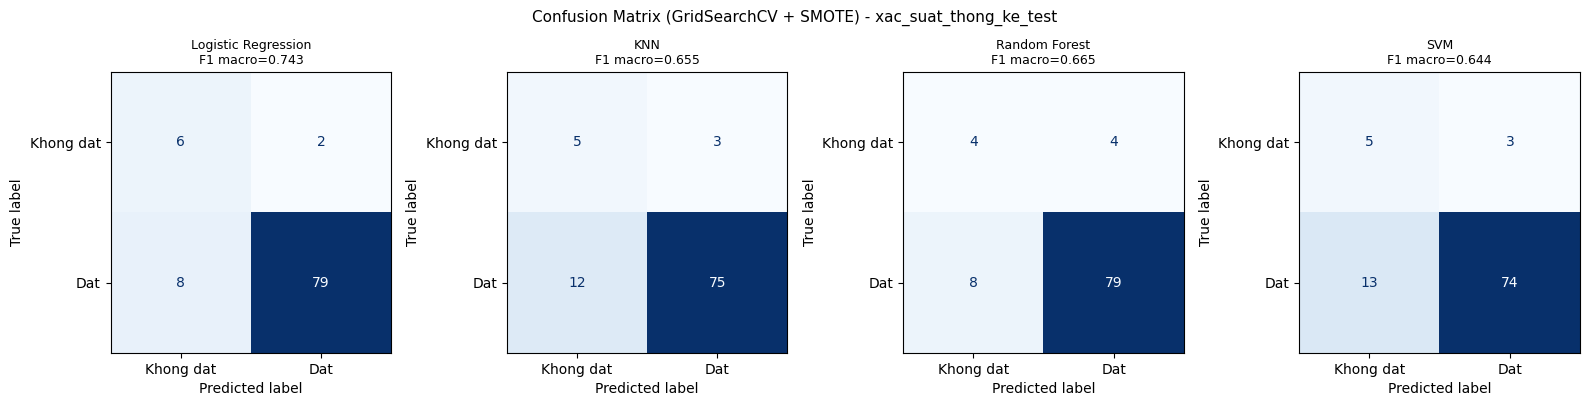

In [88]:
test_rows = []
best_model_info = {"name": None, "f1_macro": -1}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (name, pipe) in zip(axes, tuned_pipes.items()):
    yp = pipe.predict(Xte_sel)
    pp = pipe.predict_proba(Xte_sel)

    acc   = accuracy_score(yte, yp)
    p_mac = precision_score(yte, yp, average="macro",    zero_division=0)
    r_mac = recall_score(yte, yp,    average="macro",    zero_division=0)
    f_mac = f1_score(yte, yp,        average="macro",    zero_division=0)
    p_w   = precision_score(yte, yp, average="weighted", zero_division=0)
    r_w   = recall_score(yte, yp,    average="weighted", zero_division=0)
    f_w   = f1_score(yte, yp,        average="weighted", zero_division=0)
    ll    = log_loss(yte, pp)

    test_rows.append({
        "Mo hinh":            name,
        "Accuracy":           round(acc,   4),
        "Precision (macro)":  round(p_mac, 4),
        "Recall (macro)":     round(r_mac, 4),
        "F1 (macro)":         round(f_mac, 4),
        "Precision (weighted)": round(p_w, 4),
        "Recall (weighted)":    round(r_w,  4),
        "F1 (weighted)":        round(f_w,  4),
        "Log Loss":           round(ll,   4),
    })

    if f_mac > best_model_info["f1_macro"]:
        best_model_info = {"name": name, "f1_macro": f_mac}

    cm = confusion_matrix(yte, yp)
    ConfusionMatrixDisplay(cm, display_labels=["Khong dat", "Dat"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nF1 macro={f_mac:.3f}", fontsize=9)

plt.suptitle(f"Confusion Matrix (GridSearchCV + SMOTE) - {TARGET}", fontsize=11)
plt.tight_layout(); plt.show()

In [89]:
test_df = pd.DataFrame(test_rows).sort_values("F1 (macro)", ascending=False)
print("Ket qua tren TEST SET (sap theo F1 macro):")
display(test_df)

print(f"\nBEST MODEL: {best_model_info['name']}")
print(f"   F1 macro = {best_model_info['f1_macro']:.4f}")

best_pipe = tuned_pipes[best_model_info["name"]]
print(f"\nClassification Report - {best_model_info['name']}:")
print(classification_report(yte, best_pipe.predict(Xte_sel),
      target_names=["Khong dat (0)", "Dat (1)"], zero_division=0))

Ket qua tren TEST SET (sap theo F1 macro):


,Mo hinh,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),Log Loss
0,Logistic Regression,0.8947,0.7019,0.8290,0.7430,0.9293,0.8947,0.9072,0.3716
2,Random Forest,0.8737,0.6426,0.7040,0.6647,0.8997,0.8737,0.8848,0.2684
1,KNN,0.8421,0.6278,0.7435,0.6545,0.9053,0.8421,0.8662,2.0960
3,SVM,0.8316,0.6194,0.7378,0.6435,0.9035,0.8316,0.8588,0.2897



BEST MODEL: Logistic Regression
   F1 macro = 0.7430

Classification Report - Logistic Regression:
               precision    recall  f1-score   support

Khong dat (0)       0.43      0.75      0.55         8
      Dat (1)       0.98      0.91      0.94        87

     accuracy                           0.89        95
    macro avg       0.70      0.83      0.74        95
 weighted avg       0.93      0.89      0.91        95



## 11. Du doan sinh vien nguy co truot - Ca 6 mon [FIX 5]

> **Khong co data leakage**: model chi `fit` tren 80% train, sau do `predict` toan bo dataset.

In [66]:
# [FIX 8] Moi mon dung GridSearchCV voi cung param_grids -> ket qua nhat quan
all_fail, summary_models = [], []

def compute_selected_features(Xtr_, ytr_, k_smote, feat_cols,
                               avg_rank_threshold=8, corr_threshold=0.8):
    """Tinh SELECTED_FEATURES tren train set cua tung mon."""
    imp_tmp = SimpleImputer(strategy="median")
    Xtr_imp = pd.DataFrame(imp_tmp.fit_transform(Xtr_), columns=feat_cols)
    Xtr_sm_, ytr_sm_ = new_smote(k_smote).fit_resample(Xtr_imp, ytr_)
    Xtr_sm_ = pd.DataFrame(Xtr_sm_, columns=feat_cols)

    sel_f = SelectKBest(f_classif, k="all").fit(Xtr_sm_, ytr_sm_)
    mi    = mutual_info_classif(Xtr_sm_, ytr_sm_, random_state=RANDOM_STATE)
    rf_fi = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE).fit(Xtr_sm_, ytr_sm_)
    rdf = pd.DataFrame({
        "Dac trung": feat_cols,
        "F-score":   sel_f.scores_,
        "Mut.Info":  mi,
        "RF Imp.":   rf_fi.feature_importances_,
    })
    rdf["Avg Rank"] = (
        rdf["F-score"].rank(ascending=False) +
        rdf["Mut.Info"].rank(ascending=False) +
        rdf["RF Imp."].rank(ascending=False)) / 3

    candidates = rdf[rdf["Avg Rank"] <= avg_rank_threshold]["Dac trung"].tolist()
    corr_mat = Xtr_sm_[candidates].corr().abs()
    selected = candidates.copy()
    for i in range(len(candidates)):
        for j in range(i + 1, len(candidates)):
            f1, f2 = candidates[i], candidates[j]
            if f1 in selected and f2 in selected:
                if corr_mat.loc[f1, f2] > corr_threshold:
                    r1 = rdf[rdf["Dac trung"] == f1]["Avg Rank"].values[0]
                    r2 = rdf[rdf["Dac trung"] == f2]["Avg Rank"].values[0]
                    selected.remove(f2 if r1 <= r2 else f1)
    return selected


for tgt in TARGET_COLS:
    print(f"\n=== {tgt} ===")
    Xf_, yf_, Xtr_, Xte_, ytr_, yte_, itr_, ite_ = prepare(tgt)
    k_ = min(2, int(ytr_.value_counts().min()) - 1)

    sel_feat_ = compute_selected_features(Xtr_, ytr_, k_, FEAT_COLS)
    print(f"  Selected features ({len(sel_feat_)}): {sel_feat_}")

    Xtr_sel_ = Xtr_[sel_feat_]
    Xte_sel_ = Xte_[sel_feat_]
    Xf_sel_  = Xf_[sel_feat_]

    fitted_pipes_, sel_rows_ = {}, []
    for nm_, pipe_ in build_models(k_).items():
        grid_ = GridSearchCV(pipe_, param_grids[nm_], cv=cv5,
                             scoring="f1_macro", n_jobs=1, verbose=0)
        grid_.fit(Xtr_sel_, ytr_)
        best_est_ = grid_.best_estimator_
        fitted_pipes_[nm_] = best_est_
        yp_  = best_est_.predict(Xte_sel_)
        rec_ = recall_score(yte_, yp_, labels=[0], average=None, zero_division=0)[0]
        f1_  = f1_score(yte_, yp_, average="macro", zero_division=0)
        sel_rows_.append({"Model": nm_, "Recall_fail": rec_, "F1_macro": f1_})
        print(f"  {nm_:22s}: RecFail={rec_:.3f}  F1m={f1_:.3f}")

    sel_df_  = pd.DataFrame(sel_rows_).sort_values(
        ["Recall_fail", "F1_macro"], ascending=[False, False]).reset_index(drop=True)
    best_nm_ = sel_df_.loc[0, "Model"]
    best_pp_ = fitted_pipes_[best_nm_]

    # [FIX 5] Predict toan bo dataset - model chi fit tren 80%
    yp_full   = best_pp_.predict(Xf_sel_)
    fail_mask = (yp_full == 0)
    ids_full  = df.loc[yf_.index, "student_id"].reset_index(drop=True)

    fail_df_ = pd.DataFrame({
        "student_id": ids_full[fail_mask].values,
        "mon_hoc":    tgt,
        "du_doan":    "fail",
        "thuc_te":    yf_.values[fail_mask],
    })
    all_fail.append(fail_df_)
    summary_models.append({
        "Mon":          tgt,
        "Best Model":   best_nm_,
        "Num Features": len(sel_feat_),
        "Recall Fail":  round(sel_df_.loc[0, "Recall_fail"], 4),
        "F1 macro":     round(sel_df_.loc[0, "F1_macro"],    4),
        "Du doan Fail": int(fail_mask.sum()),
        "Thuc te Fail": int((yf_ == 0).sum()),
    })

sum_df = pd.DataFrame(summary_models)
print("\n\nBest model tung mon (GridSearchCV):"); display(sum_df)



=== do_an_1_test ===
  Selected features (8): ['dai_so_tuyen_tinh', 'giai_tich', 'giai_tich_so', 'lap_trinh_python_co_ban', 'cau_truc_du_lieu_va_giai_thuat', 'co_so_du_lieu', 'lap_trinh_huong_doi_tuong', 'lap_trinh_ung_dung_windows_form']
  Logistic Regression   : RecFail=0.812  F1m=0.723
  KNN                   : RecFail=0.812  F1m=0.647
  Random Forest         : RecFail=0.812  F1m=0.734
  SVM                   : RecFail=0.812  F1m=0.713

=== kiem_thu_phan_mem_test ===
  Selected features (8): ['giai_tich', 'giai_tich_so', 'lap_trinh_python_co_ban', 'cau_truc_du_lieu_va_giai_thuat', 'co_so_ky_thuat_lap_trinh', 'lap_trinh_huong_doi_tuong', 'lap_trinh_ung_dung_windows_form', 'tieng_anh_tang_cuong']
  Logistic Regression   : RecFail=0.600  F1m=0.620
  KNN                   : RecFail=0.400  F1m=0.545
  Random Forest         : RecFail=0.600  F1m=0.711
  SVM                   : RecFail=0.400  F1m=0.628

=== thiet_ke_web_co_ban_test ===
  Selected features (8): ['dai_so_tuyen_tinh', 'giai_t

,Mon,Best Model,Num Features,Recall Fail,F1 macro,Du doan Fail,Thuc te Fail
0,do_an_1_test,Random Forest,8,0.8125,0.7338,162,81
1,kiem_thu_phan_mem_test,Random Forest,8,0.6000,0.7110,60,25
2,thiet_ke_web_co_ban_test,Logistic Regression,8,0.7500,0.7369,118,58
3,cong_nghe_phan_mem_test,Random Forest,8,0.6250,0.7206,69,42
4,tieng_anh_1_test,Logistic Regression,7,0.6667,0.7467,58,32
5,xac_suat_thong_ke_test,Logistic Regression,8,0.7500,0.7279,93,39


In [67]:
final_fail  = pd.concat(all_fail, ignore_index=True)
student_sum = (
    final_fail.groupby("student_id")["mon_hoc"].apply(list)
    .reset_index().rename(columns={"mon_hoc":"predicted_fail_subjects"})
)
student_sum["num_fail"] = student_sum["predicted_fail_subjects"].apply(len)
student_sum = student_sum.sort_values(["num_fail","student_id"], ascending=[False,True])

print("Sinh vien nguy co truot nhieu mon nhat:")
display(student_sum.head(30))

Sinh vien nguy co truot nhieu mon nhat:


,student_id,predicted_fail_subjects,num_fail
2,10121055,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
4,10121101,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
30,10121472,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
36,10121578,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
39,10121640,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
61,10122090,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
76,10123038,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
81,10123119,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
87,10123163,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6
94,10123210,"[do_an_1_test, kiem_thu_phan_mem_test, thiet_k...",6


In [68]:
with pd.ExcelWriter("fail_students_fixed.xlsx") as writer:
    final_fail.to_excel(writer, sheet_name="fail_by_subject", index=False)
    student_sum.to_excel(writer, sheet_name="fail_by_student", index=False)
    sum_df.to_excel(writer, sheet_name="best_models", index=False)

print("Da xuat: fail_students_fixed.xlsx")

Da xuat: fail_students_fixed.xlsx
